In [4]:
from deap import creator, base, tools, algorithms
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial

random.seed(42)

# Загрузка и предобработка данных

In [5]:
df = pd.read_csv('Automated_RSZ_distribution_enc.csv', sep=';')

C:\Users\dkali\AppData\Local\Temp\ipykernel_33972\1375559738.py:1: DtypeWarning:

Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.



In [6]:
df = df.drop(index=df[(df['Инспектор, сменивший статус'].isna()) & (df['Статус РСЗ'] != 'Новое')].index)
df.loc[df['Код НО инспектора, сменившего стат']=='000n', 'Код НО инспектора, сменившего стат'] = 0

In [7]:
df.drop_duplicates(inplace=True)
df['Дата выявления'] = pd.to_datetime(df['Дата выявления'], format='%Y-%m-%d %H:%M:%S')
df['Дата изменения статуса РСЗ'] = pd.to_datetime(df['Дата изменения статуса РСЗ'], format='%Y-%m-%d %H:%M:%S')
df['Код НО инспектора, сменившего стат'] = df['Код НО инспектора, сменившего стат'].astype(int)

In [8]:
print("Общая информация о данных:")
print(f'Общее количество записей: {df.__len__()}')
print(f'Столбцы: {df.columns.to_list()}')

# Анализ статусов
print("\nРаспределение по статусам:")
print(df['Статус РСЗ'].value_counts())

# Анализ типов задач
print("\nРаспределение по типам:")
print(df['Тип'].value_counts())

Общая информация о данных:
Общее количество записей: 1373805
Столбцы: ['№ схемы/риска', 'Тип', 'Дата выявления', 'Статус РСЗ', 'Дата изменения статуса РСЗ', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Потенциальный ущерб, руб', 'Номер проверки', 'ИНН НП', 'КПП', 'Наименование НП', 'Рег. номер декларации', 'Код периода', 'Период', 'Год декларации', 'Номер корректировки', 'Дата подачи декларации', 'Вид налога', 'Тип декларации', 'Дата обновления', 'Дата аннулирования НД', 'Дата окончания КНП']

Распределение по статусам:
Статус РСЗ
В работе                                                 563015
Новое                                                    331591
Нарушение подтверждено. Устранено уточнением сведений    161373
Нарушение не подтверждено                                128759
Нарушение подтверждено. Доказано                          62001
Установлены отрицательные изменения                       59883
Нарушение подтверждено. Не доказано                   

In [9]:
# Анализ инспекторов
print('Распределение по инспекторам')
print(df['Инспектор, сменивший статус'].value_counts())

Распределение по инспекторам
Инспектор, сменивший статус
30250-fzog-omkeqi-eoszfzxy    42098
75845-oadk-xuuthe-iorbemnl    13638
56214-vxdc-qmbdkl-lgvrvnzm     7195
99404-xycu-argxqc-vbquafed     5432
33199-xfft-ohhuuq-yhngrscb     5104
                              ...  
58324-hxuk-bacobc-ujljwkcp        1
95210-qwbs-eufful-jxdqwejq        1
75983-eksl-zfctez-jyfpmnmf        1
12565-jdzy-xmdkag-vncgczdf        1
20936-bsto-gmxzvo-jqdgklkg        1
Name: count, Length: 12635, dtype: int64


In [10]:
df['Тип'] = df['Тип'].replace(
    to_replace={
        'Риск_долго': 'RISK_LONG',
        'Риск_быстро': 'RISK_SHORT',
        'Схема': 'SCHEMA', 
        'Задание': 'Task'
    },
    regex=True)

## Распределение баллов по задачам и инспекторам в соответствии с автостатусами

In [41]:
Auto_Stats = pd.DataFrame({
 'Новое':                                                   [0, 0, 0, 0],
 'В работе':                                                [0, 0, 0, 0],
 'Нарушение подтверждено. Устранено уточнением сведений':   [100, 86, 46, 0],
 'Нарушение не подтверждено':                               [50, 43, 23 , 0],
 'Нарушение подтверждено. Доказано':                        [75, 65, 35, 0],
 'Установлены отрицательные изменения':                     [0, 0, 0, 0],
 'Нарушение подтверждено. Не доказано':                     [40, 34, 18, 0],
 'Не доказано':                                             [40, 34, 18, 0],
 'Декларация аннулирована':                                 [60, 52, 28, 0],
 'Разакцептование':                                         [0, 0, 0, 0],
 'Архив':                                                   [0, 0, 0, 0],
 'Ожидает обработки':                                       [0, 0, 0, 0],
 'Разакцептован':                                           [0, 0, 0, 0],
 'На проверке':                                             [0, 0, 0, 0],
 'Выполнено':                                               [0, 0, 0, 3], 
 'Не выполнено':                                            [0, 0, 0, 0],
}).transpose()
Auto_Stats.columns = ['SCHEMA', 'RISK_LONG', 'RISK_SHORT', 'TASK']
Auto_Stats

,SCHEMA,RISK_LONG,RISK_SHORT,TASK
Новое,0,0,0,0
В работе,0,0,0,0
Нарушение подтверждено. Устранено уточнением сведений,100,86,46,0
Нарушение не подтверждено,50,43,23,0
Нарушение подтверждено. Доказано,75,65,35,0
Установлены отрицательные изменения,0,0,0,0
Нарушение подтверждено. Не доказано,40,34,18,0
Не доказано,40,34,18,0
Декларация аннулирована,60,52,28,0
Разакцептование,0,0,0,0


In [42]:
all_scores = [Auto_Stats.loc[stat, df.iloc[i, 1]] for i, stat in enumerate(df['Статус РСЗ'])]
df['Score'] = all_scores

In [13]:
N_ended_works = df[df['Score'] > 0].groupby('Инспектор, сменивший статус')['Score'].count()
N_ended_works

Инспектор, сменивший статус
11111-iyri-uwwjst-chzuradt    54
11125-pwzz-fygsdc-pkejzjik    42
11130-paro-ajcqzn-ceqdxcxw     2
11131-sfab-goldts-zajlmqic    10
11132-fgon-zinrmu-koxfcmwo     3
                              ..
99958-muml-yjokvs-nqgsmcoi    15
99962-xuim-lxusxl-liyswlzm    31
99969-qxfc-eirral-zrzcrexd    35
99981-ohqn-cntirp-negogxqs     9
99989-hjji-oyrmzp-aizmuiyk    10
Name: Score, Length: 10972, dtype: int64

## Создание датасета о инструктарах

In [14]:
inspectors_df = pd.DataFrame(df.groupby('Инспектор, сменивший статус')['Код НО инспектора, сменившего стат'].last())
inspectors_efficiency = df[df['Score'] > 0].groupby('Инспектор, сменивший статус')['Score'].sum()/N_ended_works/100
inspectors_df = inspectors_df.merge(inspectors_efficiency, how='left', left_index=True, right_index=True)
inspectors_df.fillna(0, inplace=True)
inspectors_df['Experience'] = [np.random.random()/2 for i in range(len(inspectors_df))]
inspectors_df['Qualification'] = inspectors_df['Score'] + inspectors_df['Experience']

mask = inspectors_df['Qualification'] >= 0.71

# Используем np.where для каждого столбца
inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
inspectors_df['p_RISK_LONG'] = np.where(mask, 0.5, 0)
inspectors_df['p_RISK_SHORT'] = np.where(mask, 0, 0.5)
inspectors_df['p_TASK'] = np.where(mask, 0, 0.5)
inspectors_df

,"Код НО инспектора, сменившего стат",Score,Experience,Qualification,p_SCHEMA,p_RISK_LONG,p_RISK_SHORT,p_TASK
"Инспектор, сменивший статус",,,,,,,,
11111-iyri-uwwjst-chzuradt,3700,0.305926,0.433075,0.739001,0.5,0.5,0.0,0.0
11125-pwzz-fygsdc-pkejzjik,2100,0.350952,0.146289,0.497241,0.0,0.0,0.5,0.5
11130-paro-ajcqzn-ceqdxcxw,6608,0.750000,0.200339,0.950339,0.5,0.5,0.0,0.0
11131-sfab-goldts-zajlmqic,1100,0.466000,0.204414,0.670414,0.0,0.0,0.5,0.5
11132-fgon-zinrmu-koxfcmwo,2632,0.800000,0.299031,1.099031,0.5,0.5,0.0,0.0
...,...,...,...,...,...,...,...,...
99958-muml-yjokvs-nqgsmcoi,7720,0.410667,0.409135,0.819801,0.5,0.5,0.0,0.0
99962-xuim-lxusxl-liyswlzm,2100,0.337742,0.265647,0.603389,0.0,0.0,0.5,0.5
99969-qxfc-eirral-zrzcrexd,7724,0.832857,0.028175,0.861033,0.5,0.5,0.0,0.0


## Подготовка нераспределённых РСЗ

In [15]:
df[df['Статус РСЗ'] == 'Новое']['Инспектор, сменивший статус'].isna().sum()

np.int64(331591)

In [16]:
df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])
grouped_df = df.groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Инспектор, сменивший статус']].last()
new_df = grouped_df[grouped_df['Статус РСЗ'] == 'Новое']
new_df

,Статус РСЗ,Тип,"Инспектор, сменивший статус"
№ схемы/риска,,,
5227396,Новое,RISK_LONG,22142-vffv-uwgpay-pndmbuao
5244060,Новое,RISK_LONG,34005-jtnz-qxxela-gieidsfa
5245050,Новое,RISK_LONG,59615-ghxv-kfjuni-xleygzrr
5248353,Новое,RISK_LONG,58089-qfxs-xlckah-fbmqirrt
5248520,Новое,RISK_LONG,12155-twyb-tpgiqb-zodrhufq
...,...,...,...
15474052,Новое,SCHEMA,84674-dpgg-zbqjiz-zrptkumx
15474121,Новое,SCHEMA,84674-dpgg-zbqjiz-zrptkumx
15474148,Новое,SCHEMA,84674-dpgg-zbqjiz-zrptkumx


In [17]:
distribution_new_tasks = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
distribution_new_tasks.update((k, new_df['Тип'].value_counts().to_dict()[k]) for k in set(distribution_new_tasks) & set(new_df['Тип'].value_counts().to_dict()))
distribution_new_tasks

{'RISK_SHORT': 203848, 'SCHEMA': 86323, 'RISK_LONG': 40816, 'TASK': 1}

In [18]:
# Функция для разбиванию инспекторов и РСЗ по НО
def filter_by_no(no_code:int, dataframe:pd.DataFrame = new_df):
    no_inspectors_df = inspectors_df[inspectors_df['Код НО инспектора, сменившего стат'] == no_code]
    no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
    
    # Заспределяем новые задачи по НО    
    dataframe = dataframe.merge(inspectors_df[['Код НО инспектора, сменившего стат']], how='left', left_on='Инспектор, сменивший статус', right_index=True)
    dataframe['Код НО инспектора, сменившего стат'] = dataframe['Код НО инспектора, сменившего стат'].fillna(0).astype(int)
    no_df = dataframe[dataframe['Код НО инспектора, сменившего стат'] == no_code]
    # ALL_TWO = df[df['Score'] > 0]['Тип'].value_counts()
    # no_distribution_of_tasks = df[df['Score'] > 0].groupby('Код НО инспектора, сменившего стат')['Тип'].value_counts() / ALL_TWO
    # no_df_RISK_SHORT = dataframe[dataframe['Тип'] == 'RISK_SHORT'].sample(int(no_distribution_of_tasks.loc[no_code]['RISK_SHORT'] * distribution_new_tasks['RISK_SHORT']))
    # no_df_RISK_LONG = dataframe[dataframe['Тип'] == 'RISK_LONG'].sample(int(no_distribution_of_tasks.loc[no_code]['RISK_LONG'] * distribution_new_tasks['RISK_LONG']))
    # no_df_SCHEMA = dataframe[dataframe['Тип'] == 'SCHEMA'].sample(int(no_distribution_of_tasks.loc[no_code]['SCHEMA'] * distribution_new_tasks['SCHEMA']))
    # no_df = pd.concat([no_df_RISK_SHORT, no_df_RISK_LONG])
    # no_df = pd.concat([no_df, no_df_SCHEMA])
    
    return no_inspectors_df, no_df, 

In [19]:
def start_data_prep(inspectors_df: pd.DataFrame, df: pd.DataFrame):
    # Расчёт вероятности передачи определённого типа задачи сотруднику --> np.array(сотрудники, типы задач)
    task_prob = [inspectors_df['p_SCHEMA'].to_list(), inspectors_df['p_RISK_LONG'].to_list(), inspectors_df['p_RISK_SHORT'].to_list(), inspectors_df['p_TASK'].to_list(),]
    task_prob = np.array([*zip(*task_prob)])
    
    # Определения числа распределяемых задач и числа сотрудников --> int, int
    N, M = df.__len__(), inspectors_df.__len__()
    
    # Создание массива хранящего в себе тип задачи по порядку --> np.array(число распределяемых задач)
    task_cat = df['Тип'].to_numpy()
    
    # Создание словаря хранящего количество распределяемых задач данного типа --> dict()
    den_TNO = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
    den_TNO.update((k, df['Тип'].value_counts().to_dict()[k]) for k in set(den_TNO) & set(df['Тип'].value_counts().to_dict()))
    
    return task_prob, N, M, task_cat, den_TNO

### Функция расчёта нагрузки и эффективности

In [20]:
def evaluation(individual: list, den_TNO: dict, task_cat: np.array, task_prob: np.array, M: int, results: bool = False):
    K1, K2, K3, K4 = 100, 80, 46, 3
    K_SUM = K1 + K2 + K3 + K4
    cnt = {cat: np.zeros(M, dtype=int) for cat in den_TNO}    
    for j, emp_idx in enumerate(individual):
        cnt[task_cat[j]][emp_idx] += 1
        
    nu = (
        cnt["SCHEMA"]     / den_TNO["SCHEMA"]     * K1 +
        cnt["RISK_LONG"]  / den_TNO["RISK_LONG"]  * K2 +
        cnt["RISK_SHORT"] / den_TNO["RISK_SHORT"] * K3 +
        cnt["TASK"]       / den_TNO["TASK"]       * K4
    ) / K_SUM * 100
    
    efficiency = (
        cnt["SCHEMA"]     * task_prob[:, 0]   / den_TNO["SCHEMA"]     +
        cnt["RISK_LONG"]  * task_prob[:, 1]   / den_TNO["RISK_LONG"]  +
        cnt["RISK_SHORT"] * task_prob[:, 2]   / den_TNO["RISK_SHORT"] +
        cnt["TASK"]       * task_prob[:, 3]   / den_TNO["TASK"]       
    ).sum() *100
    
    load = nu.max()
    if not results:
        return load, efficiency,
    return nu, efficiency,

### Функция оптимизации

In [ ]:
def Multi_optimization(task_prob: np.array, N: int, M:int,  task_cat: np.array, den_TNO: dict, 
                       population_size: int = 100, epoches: int = 50, p_crossing: float = 0.5, p_mutation: float = 0.2):
        
    func = partial(evaluation, den_TNO=den_TNO, task_cat=task_cat, task_prob=task_prob, M=M)
    
    creator.create('FintesMulti', base.Fitness, weights=(-1, 1)) # load ↓, efficiency ↑
    creator.create('Individual', list, fitness=creator.FintesMulti)
    
    toolbox = base.Toolbox()
    fit1_stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
    fit2_stats = tools.Statistics(key=lambda ind: ind.fitness.values[1])

    mstats = tools.MultiStatistics(fit1=fit1_stats, fit2=fit2_stats)
    mstats.register("min", np.min)
    mstats.register("avg", np.mean)
    mstats.register("max", np.max)

    toolbox.register('attr_int', np.random.randint, 0, M)
    toolbox.register('individual', tools.initRepeat, creator.Individual, 
                    toolbox.attr_int, N)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", func)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register('mutate', tools.mutUniformInt,  low=0, up=M-1, indpb=0.05)
    toolbox.register('select', tools.selNSGA2)
    
    hall_of_fame = tools.HallOfFame(np.inf)
    population = toolbox.population(population_size)
    pop, logbook = algorithms.eaMuPlusLambda(population, 
                                    toolbox, 
                                    mu=population_size,
                                    lambda_=population_size,
                                    cxpb=p_crossing, mutpb=p_mutation, ngen=epoches, 
                                    halloffame=hall_of_fame,
                                    stats=mstats, verbose=True)
    
    pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    uniq_pareto = []
    for ind in pareto:
        if ind not in uniq_pareto:
            uniq_pareto.append(ind)
            
    print("Len of Pareto set:", len(uniq_pareto))
    return hall_of_fame, uniq_pareto
    

## Оптимизация по выбраному НО

In [22]:
df['Код НО инспектора, сменившего стат'].nunique()

437

In [23]:
no_inspectors_df, no_df = filter_by_no(3700)
task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df)
hall_of_fame, uniq_pareto = Multi_optimization(task_prob, N, M, task_cat, den_TNO)

C:\Users\dkali\AppData\Local\Temp\ipykernel_33972\1546366528.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



   	      	                 fit1                 	                 fit2                 
   	      	--------------------------------------	--------------------------------------
gen	nevals	avg    	gen	max    	min    	nevals	avg    	gen	max    	min   	nevals
0  	100   	3.03228	0  	4.85929	2.29725	100   	67.0423	0  	75.1867	58.751	100   
1  	66    	2.77649	1  	3.90585	2.29725	66    	68.8169	1  	75.1867	61.8905	66    
2  	73    	2.68294	2  	3.72303	2.28269	73    	69.9885	2  	76.6077	61.8602	73    
3  	71    	2.66217	3  	3.72303	2.28269	71    	71.2573	3  	77.1631	61.8602	71    
4  	69    	2.64905	4  	3.72303	2.28269	69    	71.8216	4  	77.1631	63.5551	69    
5  	78    	2.63994	5  	3.72303	2.24491	78    	72.3623	5  	77.4818	63.5551	78    
6  	62    	2.55197	6  	3.70848	2.24491	62    	72.9536	6  	79.9271	67.2876	62    
7  	71    	2.49505	7  	3.67989	2.24491	71    	72.8847	7  	80.5645	67.2876	71    
8  	72    	2.49562	8  	3.31374	2.24491	72    	73.7422	8  	80.5645	67.9043	72    
9  	72    	2.4

### Анализ существуюшей нагрузки и её эффективности

In [ ]:
current_df = grouped_df[grouped_df['Статус РСЗ'] == 'В работе']
current_no_inspectors_df, current_no_df = filter_by_no(3700, current_df)
current_task_prob, current_N, current_M, current_task_cat, current_den_TNO = start_data_prep(current_no_inspectors_df, current_no_df)
current_no_df = current_no_df.merge(current_no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
current_individ = current_no_df['Inspector index'].to_list()

current_load, current_eff = evaluation(current_individ, den_TNO=current_den_TNO, task_cat=current_task_cat, M=current_M, task_prob=current_task_prob, results=True)
sorted_current_load = np.sort(current_load)[::-1]
index = [i for i in range(len(current_no_inspectors_df))]

plt.bar(x=index, height=sorted_current_load, width=1, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
plt.ylabel('Текущая взвешенная нагрузка (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Эффективность {round(current_eff, 2)}%')

### Анализ результатов оптимизации распределения новых задач

In [ ]:
index = [i for i in range(len(no_inspectors_df))]
for pareto_ind in uniq_pareto:
    load, eff = evaluation(pareto_ind, den_TNO, task_cat, task_prob, M,results=True)
    sorted_load = np.sort(load)[::-1]
    current_mean = load.mean()
    std = load.std()
    plt.bar(x=index, height=sorted_load, width=1, label='Распределённая нагрузка', color='lightblue',  alpha = 0.7)
    plt.axhline(y=current_mean, color='red', linestyle='--', alpha=0.7)
    plt.fill_between(x=index, y1=current_mean - std, y2=current_mean + std,
                 color="orange", alpha=0.2, label=f"±1 σ ({std:.2f} %)")
    plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
    plt.ylabel('Взвешенная нагрузка (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Эффективность {round(eff, 2)}%')
    plt.show()
# improvement = ((current_mean - final_mean) / current_mean * 100) if current_mean > 0 else 0
# ax1.axhline(y=final_mean, color='blue', linestyle='--', alpha=0.7)

In [35]:
all_generations = hall_of_fame.items
# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1]] for value in populations]
populations = [*zip(*populations)]
populations.append(tuple(all_generations))

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]
pareto_front.append(tuple(uniq_pareto))

In [43]:
import plotly.graph_objects as go
from ipywidgets import Output, VBox, HTML, FloatRangeSlider, Button
from IPython.display import display
import csv


# Виджет вывода параметров
output_area = Output()

# Выбранная точка для сохранения
selected_point = {}

# График
fig = go.FigureWidget()

# Все индивиды
fig.add_trace(go.Scatter(
    x=populations[0], y=populations[1],
    mode='markers',
    marker=dict(color='royalblue', size=6, opacity=0.7),
    name='Individuals',
    customdata=populations[2],
    hovertemplate="Макс. нагрузка: %{x:.2f}<br>Эффективность: %{y:.2f}"
))

# Парето фронт
fig.add_trace(go.Scatter(
    x=pareto_front[0], y=pareto_front[1],
    mode='lines+markers',
    marker=dict(color='crimson', size=10),
    line=dict(dash='dash'),
    name='Pareto front',
    customdata=pareto_front[2],
    hovertemplate="Макс. нагрузка: %{x:.2f}<br>Эффективность: %{y:.2f}"
))

fig.update_layout(
    title="🎯 Парето-фронт и популяция решений",
    xaxis_title='Макс. нагрузка (%)',
    yaxis_title='Эффективность (%)',
    margin=dict(l=30, r=30, t=40, b=20),
    hovermode='closest'
)

# --- Обработка клика по точке ---
def handle_click(trace, points, selector):
    if points.point_inds:
        idx = points.point_inds[0]
        params = trace.customdata[idx]
        selected_point['data'] = params

        # HTML-таблица
        rows = ''.join([f"<tr><td>Параметр {i+1}</td><td>{val}</td></tr>" for i, val in enumerate(params)])
        html_table = f"""
        <table style="border-collapse: collapse; margin-top: 5px;">
          <thead><tr><th style="padding:4px;border:1px solid #ccc;">Параметр</th>
                     <th style="padding:4px;border:1px solid #ccc;">Значение</th></tr></thead>
          <tbody>{rows}</tbody>
        </table>
        """

        with output_area:
            output_area.clear_output()
            display(HTML(f"<b>📌 Выбрана точка ({trace.name})</b>" + html_table))
        save_button.disabled = False

fig.data[0].on_click(handle_click)
fig.data[1].on_click(handle_click)

# --- Сохранение выбранной точки ---
def save_solution(_):
    if 'data' in selected_point:
        with open('selected_solution.csv', 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([f'param_{i+1}' for i in range(len(selected_point['data']))])
            writer.writerow(selected_point['data'])
        with output_area:
            print("💾 Решение сохранено в файл selected_solution.csv")

save_button = Button(description="Сохранить решение", disabled=True, button_style='success')

save_button.on_click(save_solution)

# --- Слайдер фильтра по эффективности ---
eff_slider = FloatRangeSlider(
    value=[20, 90],
    min=0, max=100, step=1,
    description='Эффективность:',
    continuous_update=False,
    layout=dict(width='60%')
)

def apply_filter(change=None):
    min_eff, max_eff = eff_slider.value
    y_vals = populations[1]
    visible = [(min_eff <= y <= max_eff) for y in y_vals]
    new_x = [x for x, show in zip(populations[0], visible) if show]
    new_y = [y for y, show in zip(populations[1], visible) if show]
    new_data = [d for d, show in zip(populations[2], visible) if show]

    with fig.batch_update():
        fig.data[0].x = new_x
        fig.data[0].y = new_y
        fig.data[0].customdata = new_data

eff_slider.observe(apply_filter, names='value')

# --- Финальный интерфейс ---
instruction = HTML("<b>🧭 Наведите или кликните по точке для подробностей. Используйте слайдер для фильтрации.</b>")

ui = VBox([instruction, eff_slider, fig, save_button, output_area])
display(ui)


In [31]:
import plotly.graph_objects as go
from ipywidgets import Output
import ipywidgets as widgets

output_area = Output()

fig = go.FigureWidget()
# fig.update_yaxes(range=[0, 100])
# fig.update_xaxes(range=[0, 10])
fig.add_trace(go.Scatter(x=populations[0], y=populations[1], mode='markers',  marker_color="royalblue", name='populations', customdata=populations[2]))
fig.add_trace(go.Scatter(x=pareto_front[0], y=pareto_front[1], mode='markers',  marker_color="Red", name='pareto front', customdata=pareto_front[2]))
fig.update_layout(title="Distribution of individuals",
                xaxis_title='max load, %',
                yaxis_title='eff, %',
                margin=dict(l=0, r=0, t=30, b=0))
fig.update_traces(hoverinfo="all", hovertemplate="Макс. нагрузка: %{x}<br>Эффективность: %{y}")

# Функция обработки клика
def handle_click(trace, points, selector):
    if points.point_inds:
        index = points.point_inds[0]
        with output_area:
            output_area.clear_output()
            print(f"Тип данных: {trace.name}")
            print(f"Индекс точки: {index}")
            print("Список параметров:")
            # Предполагаем, что customdata[index] - это список параметров
            for i, param in enumerate(trace.customdata[index]):
                print(f"Параметр {i+1}: {param}")

# Регистрируем обработчики
fig.data[0].on_click(handle_click)
fig.data[1].on_click(handle_click)

# Отображаем график и область вывода
display(widgets.VBox([fig, output_area]))

    'data': [{'customdata': [[22, 18, 74, 10, 32, 32, 53, 61, 11, 8, 13, 50, 18,…

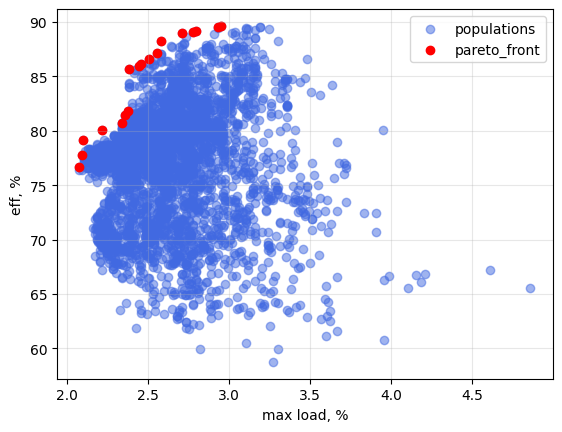

In [28]:
# vals = logbook.select("values")

# Получаем все сохраненные популяции
all_generations = hall_of_fame.items
# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1]] for value in populations]
populations = [*zip(*populations)]

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]

plt.scatter(populations[0], populations[1], c='royalblue', alpha=0.5)
plt.scatter(pareto_front[0], pareto_front[1], c='red')
plt.legend(['populations', 'pareto_front'])
plt.xlabel('max load, %')
plt.ylabel('eff, %')
plt.grid(True, alpha=0.3)